<img src="https://udemedellin.edu.co/wp-content/uploads/2022/10/logo_udemedellin2.png" width="30%">

**ESPECIALIZACIÓN EN CIENCIA DE DATOS E INTELIGENCIA ARTIFICIAL**

*INTRODUCCION A LA CIENCIA DE DATOS*<br>

DOCENTE:<br>
Mateo Cano Solis<br>

NOMBRES:
1. Santiago Castañeda Garcia
2. Andres Eduardo Medina
3. David Alejandro Montilla Orjuela



Abril 2026


---

# **Análisis Predictivo y Caracterización de la Contratación Estatal en Colombia: Un Enfoque Basado en Datos de SECOP I y II**

## **1. introducción:**
La contratación pública en Colombia representa uno de los pilares más importantes para el desarrollo socioeconómico del país. Con la transición y coexistencia de las plataformas SECOP I y SECOP II, se ha generado un volumen de información sin precedentes sobre cómo el Estado invierte sus recursos. Sin embargo, la complejidad y diversidad de estos datos exigen el uso de herramientas avanzadas de Analítica de Datos para transformar registros administrativos en conocimiento estratégico.

Este proyecto se enfoca en el estudio de los procesos de compra pública que han culminado en contratos efectivos. A través de técnicas de Aprendizaje Automático (Machine Learning), se busca descubrir patrones ocultos en las modalidades de selección, los tiempos de ejecución y la distribución de los presupuestos, permitiendo una visión técnica que aporte a la transparencia y a la eficiencia en la gestión pública

<br><br>

## **2. Objetivos:**

Objetivo General
Desarrollar un modelo de análisis basado en técnicas de aprendizaje automático para caracterizar y predecir métricas clave en los procesos de contratación estatal integrados en las plataformas SECOP I y II.

Objetivos Específicos
Realizar un Análisis Exploratorio de Datos (EDA) para identificar las tendencias de contratación por sectores, regiones y modalidades de selección.

Procesar y estandarizar la información integrada de SECOP I y II, gestionando la limpieza de datos faltantes y la codificación de variables categóricas.

Evaluar diferentes arquitecturas de modelos predictivos mediante el uso de herramientas de AutoML (como AutoGluon), con el fin de determinar el algoritmo que ofrezca mayor precisión en la clasificación o estimación de resultados contractuales.

Interpretar los resultados obtenidos para identificar qué variables (como cuantía, ubicación o tipo de entidad) tienen mayor peso en la configuración de un contrato exitoso.

<br>
VARIABLES OBSERVADAS
<br><br>

|Num|Nombre de la columna|Descripción|Nombre del campo API|Tipo de dato|
|-|-|-|-|-|
|1|Nivel Entidad|Nivel de la entidad publica que desarrolla el proceso de compra, de acuerdo a su cobertura|Nivel entidad|Texto|
|2|Código Entidad SECOP|Código de la entidad en la plataforma SEECOP|Código_entidad_en_secop|Texto |
|3|Nombre de la Entidad|Nombre de la Entidad que desarrolla el proceso de compra pública|nombre_de_la_entidad|Texto |
|4|NIT de la Entidad|	Identificador de la Entidad que desarrolla el proceso de compra pública|nit_de_la_entidad|	Texto|
|5|Departamento Entidad|	Departamento de origen de la Entidad en la plataforma SECOP|	departamento_entidad|	Texto|
|6|Municipio Entidad|	Municipio de origen de la Entidad en la plataforma SECOP|	municipio_entidad|	Texto|
|7|Estado del Proces|	Estado del proceso, de acuerdo con el flujo que se establece y a la modalidad de adquisición bajo la cual se desarrolla|	estado_del_proceso|	Texto|
|8|Modalidad de Contratación|	Modo de adquisición, de acuerdo con las características del proceso y del producto o servicio involucrados|	modalidad_de_contrataci_n|	Texto|
|9|Objeto del contrato|	Descripción detallada del producto o servicio a adquirir, definida al momento de redactar el contrato|	objeto_a_contratar|	Texto|
|10|Objeto del proceso|	Objeto de contratación registrado en la fase de publicación del proceso|	objeto_del_proceso|	Texto|
|11|Tipo de Contrato|	Tipo de contrato que se firma al finalizar el proceso de compra pública|	tipo_de_contrato|	Texto|
|12|Fecha de Firma del Contrato|	Fecha en que se firmó el contrato, sea de forma física o digital|	fecha_de_firma_del_contrato|	Marca de tiempo variable|
|13|Fecha inicio ejecución|	Fecha de Inicio de Ejecución del Contrato|	fecha_inicio_ejecuci_n|	Marca de tiempo variable|
|14|Fecha fin ejecución|	Fecha definida en el contrato como la fecha de finalización de la ejecución|	fecha_fin_ejecuci_n|	Marca de tiempo variable|
|15|ID Contrato|	Identificador en la plataforma del contrato firmado|	numero_del_contrato|	Texto|
|16|ID Proceso|	identificador en la plataforma del proceso desarrollado|	numero_de_proceso|	Texto|
|17|Valor Contrato|	Valor del contrato firmado|	valor_contrato	|numerica|
|18|Núm Raz Social Contratista|Nombre del contratista o de la empresa que proveerá los productos o servicios relacionados en el proceso de compra|num_raz_social_contratista|Texto|
|19|	URL Contrato|	URL del proceso en su correspondiente plataforma.|	url_contrato|	Texto|
|20	|Origen	|Plataforma Origen a donde pertenecen los datos|	origen	|Texto|
|21	|Tipo Documento Proveedor	|Corresponde al tipo de documento del proveedor	|tipo_documento_proveedor|	Texto|
|22|	Documento Proveedor	|Corresponde al número de documento del proveedor|	documento_proveedor	|Texto|






## **Carga de librerias y datos:**

In [1]:
#Importacion de librerias
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import seaborn as sns
import unicodedata
import re
from catboost import CatBoostRegressor
import warnings
import seaborn as sns



df = pd.read_parquet('data/datos_secop.parquet')

#visualizar todo el df en pantalla
pd.set_option('display.max_columns', None)

# generar variable para conteo final de Nas
filas_iniciales = len(df)

#numero de columnas y filas
print(f"El dataset tiene: {df.shape[0]} filas y {df.shape[1]} columnas")



El dataset tiene: 300000 filas y 22 columnas


## **Variables**

## **Visualizar el df**

In [2]:
# Mostrar  5 filas aleatorias
df.sample(5,random_state=25)

,nivel_entidad,codigo_entidad_en_secop,nombre_de_la_entidad,nit_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contrataci_n,objeto_a_contratar,objeto_del_proceso,tipo_de_contrato,fecha_de_firma_del_contrato,fecha_inicio_ejecuci_n,fecha_fin_ejecuci_n,numero_del_contrato,numero_de_proceso,valor_contrato,nom_raz_social_contratista,url_contrato,origen,tipo_documento_proveedor,documento_proveedor
98576,Territorial,706294725,MUNICIPIO DE PUERTO GAITAN,800079035,Meta,Puerto Gaitán,En ejecución,Contratación directa,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,PRESTACION DE SERVICIOS DE APOYO A LA GESTION ...,Prestación de servicios,2025-10-24T00:00:00.000,2025-10-24T00:00:00.000,2025-12-24T00:00:00.000,CO1.PCCNTR.8496546,1457-2025,5693333,DANIELA STEFFANY ROJAS ORTIZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1124818345
267521,Territorial,702730482,SUBRED INTEGRADA DE SERVICIOS DE SALUD SUR E.S...,900958564,Distrito Capital de Bogotá,Bogotá,Modificado,Contratación régimen especial,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,PRESTAR SERVICIOS COMO PROFESIONAL UNIVERSITAR...,Prestación de servicios,2025-10-02T00:00:00.000,2025-10-02T00:00:00.000,2026-01-09T00:00:00.000,CO1.PCCNTR.8401984,7218-2025,12585600,Milena Stefany Lopez Ramirez,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,1018450196
286023,Territorial,701365033,MUNICIPIO DE ARMENIA QUINDIO,890000464,Quindío,Armenia,Aprobado,Contratación directa,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,PRESTACIÓN DE SERVICIOS DE APOYO A LA GESTIÓN ...,Prestación de servicios,2025-11-27T00:00:00.000,None,2026-01-15T00:00:00.000,CO1.PCCNTR.8635700,SETTA-CD-2025-4677,3750000,Oscar Posada Yepes,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,7529900
11020,Territorial,702727421,empresa social del estado región de salud soacha.,8000068503,Cundinamarca,Soacha,Borrador,Contratación régimen especial,NO DEFINIDO,Sin Descripcion,Prestación de servicios,None,None,None,CO1.PCCNTR.272027,CO1.PCCNTR.272027,0,NO DEFINIDO,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Sin Descripcion,No Definido
219736,Territorial,702271321,(Secretaría Distrital de Integración Social),8999990619,Distrito Capital de Bogotá,No Definido,Aprobado,Contratación directa,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,PRESTAR SERVICIOS PROFESIONALES PARA REALIZAR ...,Prestación de servicios,2025-11-18T00:00:00.000,None,2026-03-12T00:00:00.000,CO1.PCCNTR.8568972,11671-2025,15137640,DASSY MILENA GUTIERREZ,https://community.secop.gov.co/Public/Tenderin...,SECOPII,Cédula de Ciudadanía,52288055


## **EDA**

In [3]:
# Obtener un resumen de la estructura del conjunto de datos:

print("\n-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------\n")
def generar_diccionario(Data):
    dicc = []
    for col in Data.columns:
        dicc.append({
            "Variable": col,
            "Tipo pandas": Data[col].dtype,
            "Cantidad de valores únicos": Data[col].nunique(),
            "Valores faltantes": Data[col].isna().sum()
        })
    return pd.DataFrame(dicc)

generar_diccionario(df)


-------TABLA CON TIPO DE VARIABLE VALORES UNICOS Y VALORES FALTANTES-------



,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,7,0
1,codigo_entidad_en_secop,object,5103,0
2,nombre_de_la_entidad,object,5239,0
3,nit_de_la_entidad,object,4200,0
4,departamento_entidad,object,38,0
5,municipio_entidad,object,1079,0
6,estado_del_proceso,object,19,0
7,modalidad_de_contrataci_n,object,31,0
8,objeto_a_contratar,object,165211,0
9,objeto_del_proceso,object,172952,1


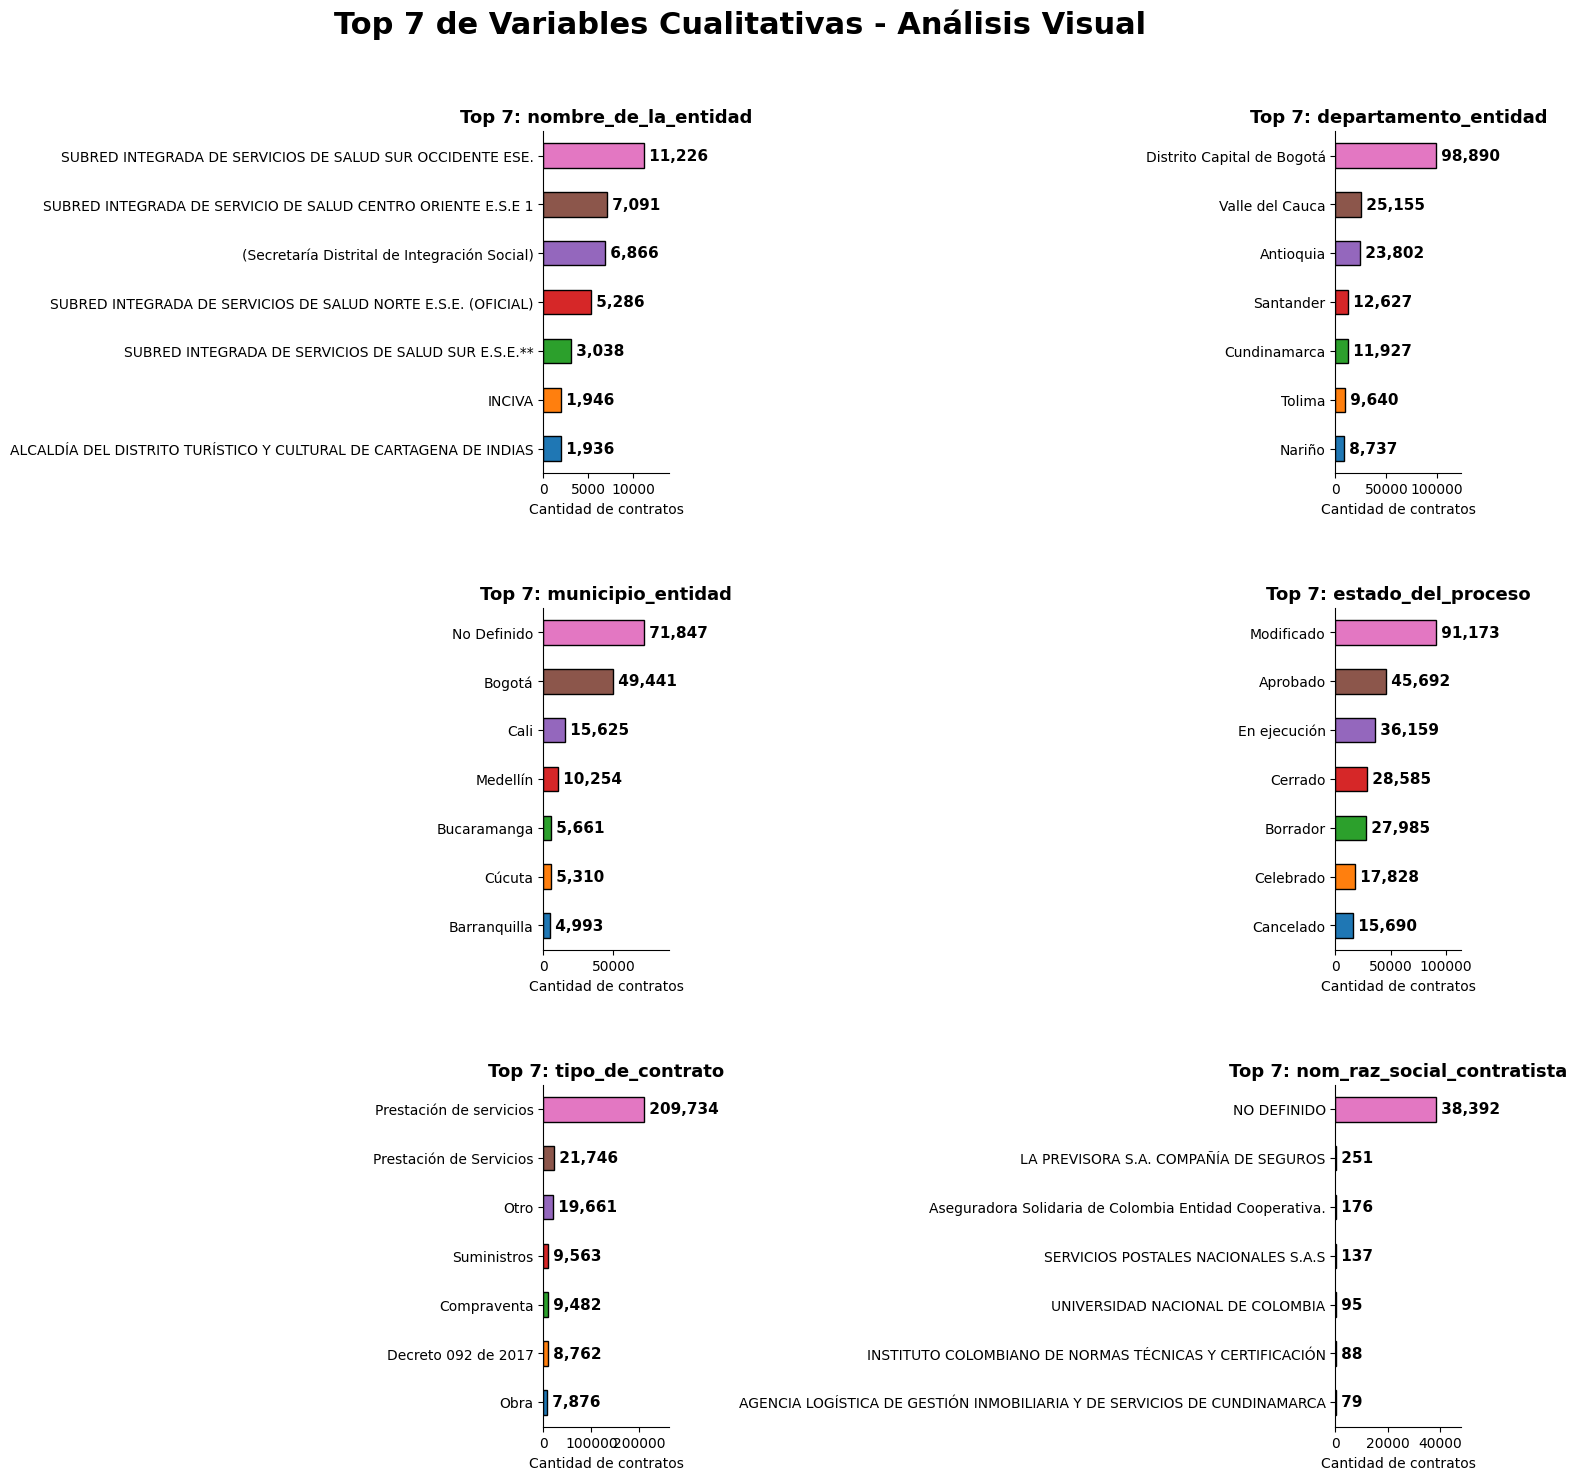

In [4]:
# 1. Configuración de variables y grid
vars_cualitativas = [
    'nombre_de_la_entidad', 'departamento_entidad', 'municipio_entidad', 
    'estado_del_proceso', 'tipo_de_contrato', 'nom_raz_social_contratista'
]

cols_grid = 2
rows_grid = math.ceil(len(vars_cualitativas) / cols_grid)

# Paleta de colores
colores_paleta = plt.cm.tab10.colors 

fig, axes = plt.subplots(rows_grid, cols_grid, figsize=(16, rows_grid * 5))
axes = axes.flatten()

for i, col in enumerate(vars_cualitativas):
    if col in df.columns:
        # Top 7 ordenado
        datos = df[col].value_counts().head(7).sort_values(ascending=True)

        ax = axes[i]
        
        # --- CAMBIO: Eliminamos 'label' para que no haya leyenda ---
        datos.plot(
            kind='barh', 
            ax=ax, 
            color=colores_paleta[:len(datos)], 
            edgecolor='black'
        )

        ax.set_title(f'Top 7: {col}', fontsize=13, fontweight='bold')
        ax.set_xlabel('Cantidad de contratos')
        ax.set_ylabel('')

        # --- CAMBIO: Eliminamos ax.legend() ---
        # La leyenda ya no se mostrará.

        # Estética
        ax.grid(False)
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Etiquetas de datos al final de la barra (aquí ya está el número)
        max_valor = datos.max()
        for p in ax.patches:
            ancho = p.get_width()
            ax.annotate(
                f' {int(ancho):,}', 
                (ancho, p.get_y() + p.get_height()/2.),
                va='center', 
                ha='left', 
                fontsize=11, 
                fontweight='bold'
            )
        
        ax.set_xlim(0, max_valor * 1.25)

    else:
        axes[i].axis('off')

# Ajustes finales
plt.tight_layout(pad=5.0)
fig.suptitle(
    'Top 7 de Variables Cualitativas - Análisis Visual',
    fontsize=22,
    fontweight='bold',
    y=1.02
)

plt.show()

## **VALOR DEL CONTRATO**

Nuestra variable target es el valor del contrato el cual intentaremos predecir pero este tiene una escala que va desde miles de  pesos a billones es por eso que para el estudio, solo trabajaremos con los contratos de 1 millon a 200 millones que es donde mas se concentra la contratacion en Colombia.

## **Renombrar columnas**

In [5]:
# Quitar guion para los nombres de las columnas
df.rename(columns={'modalidad_de_contrataci_n': 'modalidad_de_contratacion', 'fecha_inicio_ejecuci_n': 'fecha_inicio_ejecucion',
    'fecha_fin_ejecuci_n': 'fecha_fin_ejecucion'},
    inplace=True)

## **DATA CLEANING**

## **Estados del proceso**

In [6]:
df["estado_del_proceso"].unique()

array(['Terminado sin Liquidar', 'Celebrado', 'En ejecución', 'Cerrado',
       'Aprobado', 'Modificado', 'Adjudicado', 'Convocado', 'Liquidado',
       'Terminado Anormalmente después de Convocado', 'cedido',
       'Borrador', 'enviado Proveedor', 'Cancelado', 'En aprobación',
       'Suspendido', 'terminado', 'Descartado',
       'Publicación para manifestaciones de interés'], dtype=object)

Para construir un modelo que prediga el valor de contratos en SECOP, NO todos los estados son igual de útiles. Algunos representan contratos reales y ejecutados, mientras que otros son etapas preliminares o procesos cancelados.

In [7]:
estados_validos = [
    'Celebrado',
    'Adjudicado',
    'En ejecución',
    'Liquidado',
    'Terminado',
    'Terminado sin Liquidar',
    'Modificado',
    'cerrado'
]

df = df[df['estado_del_proceso'].isin(estados_validos)]

In [8]:
df.shape[0]

147247

OBSERVACION: El dataset nos quedo con 147247 filas lo cual nos dice que exisitian  27958 contratos que a la fecha no se han aprobado y fueron eliminados para nuestro estudio, ademas tenemos  75269  filas que no tienen fecha de inicio de ejecucion (fecha_inicio_ejecucion), esto puede deberse que el contrato aun no se ha iniciado por lo que no debe tener fecha de terminacion (fecha_fin_ejecucion). Buscamos las filas que no tienen fechas en ninguna de las dos columnas (fantasmas).

Pasar variables de fecha a formato datetime


In [9]:
#numero de filas sin fecha de inicio de ejcucion
filas_sin_fecha_ejecucion=df['fecha_inicio_ejecucion'].isna().sum()
print(f"el numero de filas sin fecha de inicio de ejcucion es: {filas_sin_fecha_ejecucion}")

el numero de filas sin fecha de inicio de ejcucion es: 636


In [10]:
#aplicar fomato datetime

cols = ['fecha_de_firma_del_contrato', 'fecha_inicio_ejecucion', 'fecha_fin_ejecucion']

df[cols] = df[cols].apply(
    lambda x: pd.to_datetime(x, errors='coerce').dt.normalize()
)

In [11]:
# 1. Obtenemos los índices de las filas con fecha de inicio nula
indices_sin_inicio = set(df[df['fecha_inicio_ejecucion'].isna()].index)

# 2. Obtenemos los índices de las filas con fecha de fin nula
indices_sin_fin = set(df[df['fecha_fin_ejecucion'].isna()].index)

# 3. Usamos la intersección (&) para saber cuáles no tienen NINGUNA de las dos
filas_sin_ambas = indices_sin_inicio & indices_sin_fin

print(f"Cantidad de contratos sin ambas fechas: {len(filas_sin_ambas)}")

df_fantasmas = df.loc[list(filas_sin_ambas)]


Cantidad de contratos sin ambas fechas: 636


Existen 636 contratos sin fechas de inicio y de ejecucion

In [12]:
#Elimina filas sin ambas fechas

df = df.drop(index=list(filas_sin_ambas)).copy()

In [13]:
print("-----Valores faltantes------")
df[cols].isna().sum()

-----Valores faltantes------


fecha_de_firma_del_contrato    0
fecha_inicio_ejecucion         0
fecha_fin_ejecucion            7
dtype: int64

aun tenemos 7 filas sin (fecha_inicio_ejecucion) por lo que las debemos borrar para poder obtener la duracion del del contrato en dias.

In [14]:

print(f"cantidad de filas del df {df.shape[0]}")

cantidad de filas del df 146611


## **Nueva variable duracion del contrato**

Creamos una variable que nos diga cuanto duro el contrato en dias

In [15]:
#Calculamos la duración en días
df['duracion_dias'] = (df['fecha_fin_ejecucion'] - df['fecha_inicio_ejecucion']).dt.days

#Revisamos si hay anomalías obvias de inmediato
print("Estadísticas de la duración:")
print(df['duracion_dias'].describe())

#(Duración negativa)
negativos = (df['duracion_dias'] < 0).sum()
print(f"\n Contratos con fechas invertidas: {negativos}")


Estadísticas de la duración:
count    146604.000000
mean        169.662670
std         226.039747
min        -677.000000
25%          51.000000
50%         118.000000
75%         274.000000
max        8065.000000
Name: duracion_dias, dtype: float64

 Contratos con fechas invertidas: 95


existen 95 contratos con duraciones negativas esto puede deberse a errores de digitacion, para nuestro ejercicio eliminamos esas filas, estos serian contratos a revisar, pero para nuestro estudio estos contratos no aportarian informacion, por lo que los eliminamos del dataset.

In [16]:
# 1. Filtramos para trabajar solo con duraciones lógicas (mayores a 0)
df = df[df['duracion_dias'] > 0].copy()

In [17]:
filas_finales=len(df)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas con fechas completas: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas con fechas completas: 146295

 filas iniciales dataset: 300000

 porcentaje eliminados: 51.23 %


Creamos una nueva variable llamada anio para extraer el año de la fecha de ejecucion del contrato


In [18]:
df['anio'] = df['fecha_inicio_ejecucion'].dt.year.astype('Int64')
df['mes'] = df['fecha_inicio_ejecucion'].dt.month.astype('Int64')


Eliminamos columnas innecesarias para modelar

In [19]:
#eliminar columnas que no usaremos en el modelado
columns_eliminar = ["nit_de_la_entidad",  
                    "numero_de_proceso",
                    "numero_del_contrato",
                    "objeto_a_contratar",
                    "nom_raz_social_contratista",
                    "documento_proveedor", 
                    "url_contrato",
                    "numero_del_contrato",
                    "fecha_de_firma_del_contrato",
                    "tipo_documento_proveedor",
                    "codigo_entidad_en_secop",
                    "fecha_inicio_ejecucion",
                    "fecha_fin_ejecucion",
                    "nombre_de_la_entidad"
                    ]

df= df.drop(columns=columns_eliminar)


analizamos la variable año (anio) para poder traer valor de los contratos a precio actual usando el ipc de cada año, (fuente DANE)

In [20]:
lista_anios = sorted(df['anio'].unique().tolist())
print(lista_anios)

[2007, 2008, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026, 2027]


In [21]:
#eliminemos contratos con fecha de 2027
df = df[df['anio'] != 2027]

fuente de ipc pagina DANE

In [22]:
ipc_df = pd.DataFrame({
    'anio': [2007, 2008, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025, 2026],
    'ipc': [5.69, 7.67, 3.73, 2.44, 1.94, 3.66, 6.77, 5.75, 4.09, 3.18, 3.80, 1.61, 5.62, 13.12, 9.28, 5.20, 5.10, 5.56]
})

df = df.merge(ipc_df, on='anio', how='left')

In [23]:
#creamos columna con valor actual 

ipc_base = 5.66  #IPC a marzo de 2026

df['valor_ajustado'] = df['valor_contrato'] * (ipc_base / df['ipc'])

## **Análisis de la variable valor de contrato ajustado al IPC**

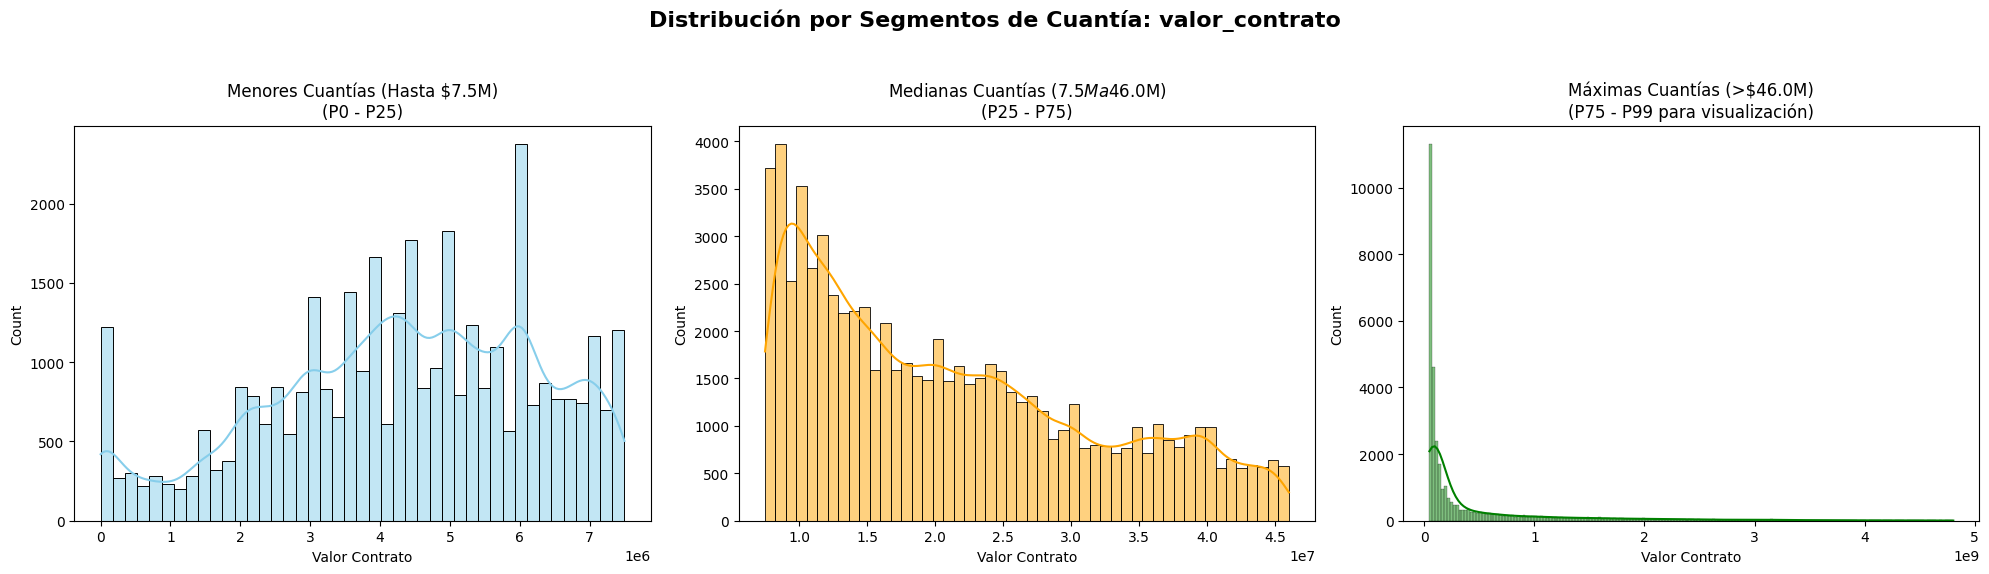

In [24]:
def graficar_segmentacion_cuantias(df, columna='valor_contrato'):
    """
    Genera tres histogramas basados en la segmentación por cuartiles (P25 y P75).
    Ayuda a visualizar la distribución de Menores, Medianas y Máximas cuantías.
    """
    # 1. Calcular los umbrales
    p25 = df[columna].quantile(0.25)
    p75 = df[columna].quantile(0.75)
    
    # 2. Configurar la figura (1 fila, 3 columnas)
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    fig.suptitle(f'Distribución por Segmentos de Cuantía: {columna}', fontsize=16, fontweight='bold')

    # --- SEGMENTO 1: Menores Cuantías ---
    data_menor = df[df[columna] <= p25]
    sns.histplot(data_menor[columna], kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title(f'Menores Cuantías (Hasta ${p25/1e6:.1f}M)\n(P0 - P25)')
    axes[0].set_xlabel('Valor Contrato')

    # --- SEGMENTO 2: Medianas Cuantías ---
    data_mediana = df[(df[columna] > p25) & (df[columna] <= p75)]
    sns.histplot(data_mediana[columna], kde=True, ax=axes[1], color='orange')
    axes[1].set_title(f'Medianas Cuantías (${p25/1e6:.1f}M a ${p75/1e6:.1f}M)\n(P25 - P75)')
    axes[1].set_xlabel('Valor Contrato')

    # --- SEGMENTO 3: Máximas Cuantías (Con recorte al P99 para que sea visible) ---
    p99 = df[columna].quantile(0.99)
    data_maxima = df[(df[columna] > p75) & (df[columna] <= p99)]
    sns.histplot(data_maxima[columna], kde=True, ax=axes[2], color='green')
    axes[2].set_title(f'Máximas Cuantías (>${p75/1e6:.1f}M)\n(P75 - P99 para visualización)')
    axes[2].set_xlabel('Valor Contrato')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


graficar_segmentacion_cuantias(df)


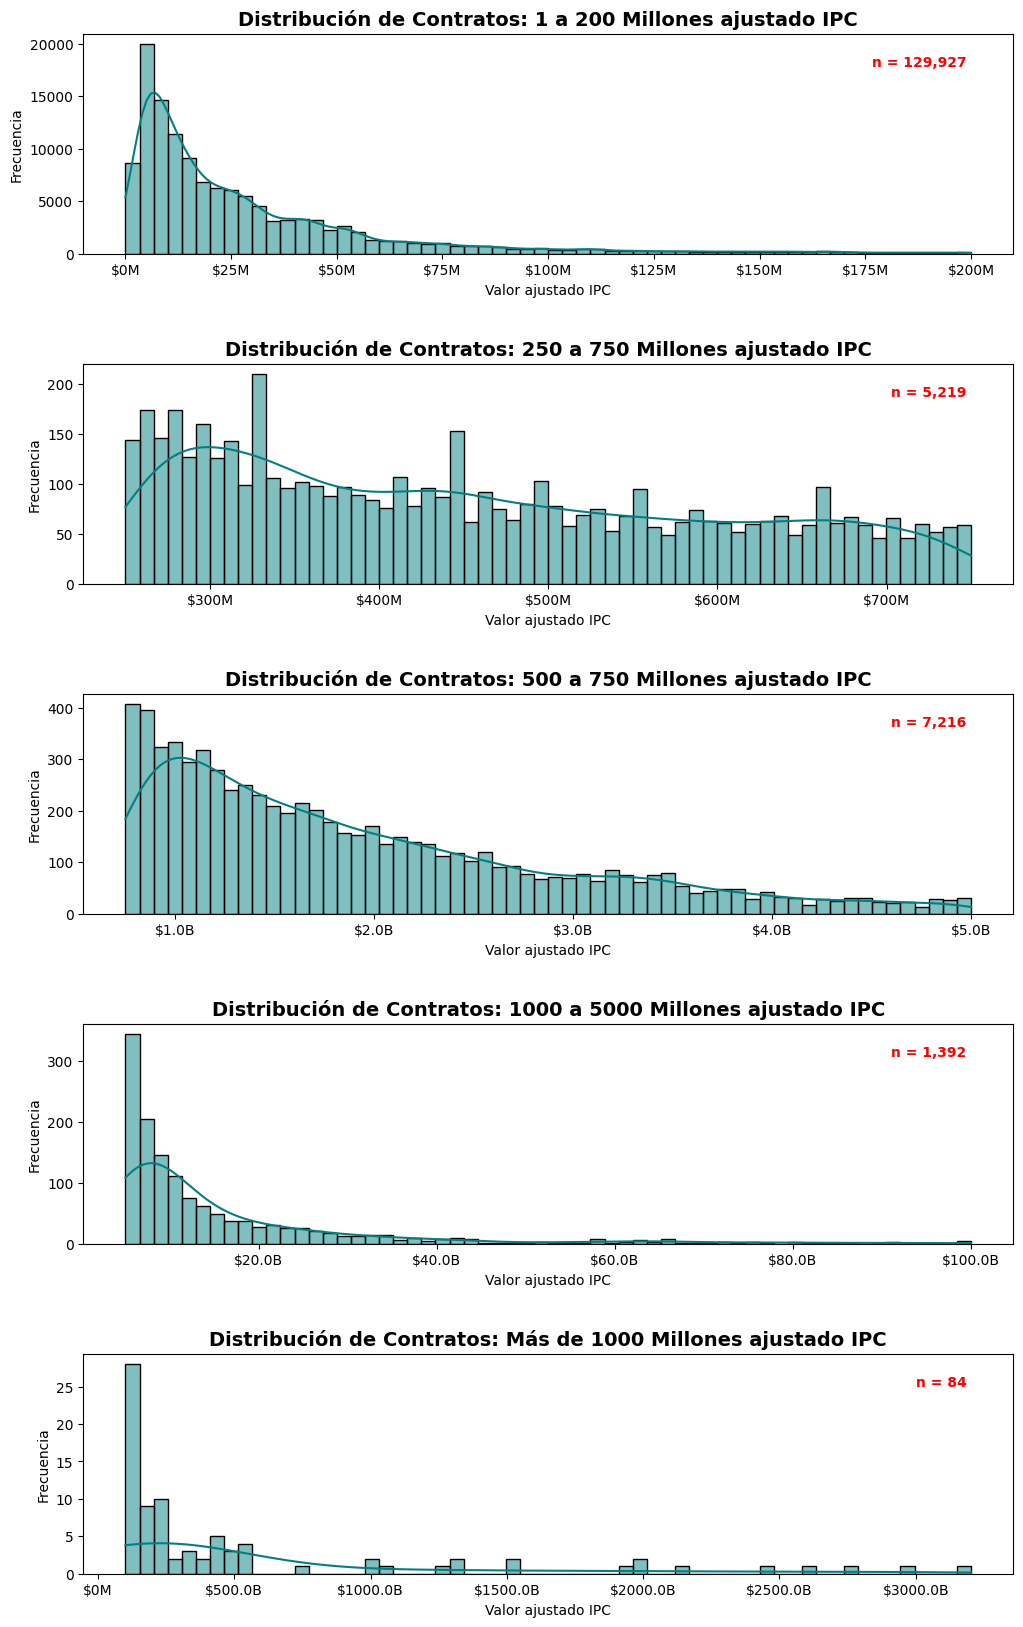

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 1. Definir los rangos (limite_inferior, limite_superior, titulo)
rangos = [
    (1, 200e6, "1 a 200 Millones ajustado IPC"),
    (250e6, 750e6, "250 a 750 Millones ajustado IPC"),
    (750e6, 5000e6, "500 a 750 Millones ajustado IPC"),
    (5000e6, 100000e6, "1000 a 5000 Millones ajustado IPC"),
    (100000e6, df['valor_contrato'].max(), "Más de 1000 Millones ajustado IPC")
]

# 2. Configurar la figura (5 filas, 1 columna)
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 20))
fig.subplots_adjust(hspace=0.5) # Espacio entre gráficas

# Función para dar formato de Millones/Billones al eje X
def format_money(x, pos):
    if x >= 1e9: return f'${x/1e9:.1f}B'
    return f'${x/1e6:.0f}M'

formatter = FuncFormatter(format_money)

# 3. Iterar y graficar
for i, (bajo, alto, titulo) in enumerate(rangos):
    # Filtrar datos para el rango actual
    data_filtrada = df[(df['valor_ajustado'] >= bajo) & (df['valor_ajustado'] <= alto)]
    
    # Graficar en el subeje correspondiente
    sns.histplot(data_filtrada['valor_ajustado'], bins=60, kde=True, ax=axes[i], color='teal')
    
    # Configurar títulos y etiquetas
    axes[i].set_title(f'Distribución de Contratos: {titulo}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Valor ajustado IPC')
    axes[i].set_ylabel('Frecuencia')
    axes[i].xaxis.set_major_formatter(formatter)
    
    # Añadir un texto con la cantidad de contratos encontrados en ese rango
    axes[i].text(0.95, 0.85, f'n = {len(data_filtrada):,}', 
                 transform=axes[i].transAxes, ha='right', fontweight='bold', color='red')

plt.show()

In [26]:
df = df[
    (df['valor_ajustado'] >= 1_000_000) &
    (df['valor_ajustado'] <= 200_000_000)
].reset_index(drop=True)

**Análisis de la distribución de la variable valor_ajustado (valor contrato con IPC)**

*Selección de la distribución para el modelado*

Se opta por trabajar con la primera distribución correspondiente al rango de 1 a 200 millones del valor ajustado del contrato por IPC, debido a las siguientes razones estadísticas y metodológicas:
En primer lugar, esta distribución presenta el mayor tamaño muestral (n ≈ 129927) en comparación con los demás subconjuntos. Esto garantiza una mayor representatividad estadística, reduciendo la varianza de los estimadores y mejorando la capacidad de generalización del modelo.
En segundo lugar, aunque la variable exhibe una asimetría positiva (cola hacia la derecha), su comportamiento es más continuo y denso en comparación con los rangos superiores, donde se observa una mayor dispersión, presencia de valores extremos y menor densidad de observaciones. Estas características en los rangos altos pueden introducir inestabilidad en el entrenamiento y sesgos en modelos predictivos.
Adicionalmente, la primera distribución refleja de manera más fiel el comportamiento típico del fenómeno estudiado (contratación), evitando que el modelo esté dominado por outliers de alto valor, los cuales, aunque relevantes, son poco frecuentes.

*Transformación propuesta*

Dado que la distribución presenta sesgo positivo, se propone aplicar una transformación logarítmica de y= log(1+x)
Esta transformación se justifica porque:
Reduce la asimetría de la distribución, acercándola a una forma más normal.
Disminuye el impacto de valores extremos.
Mejora el desempeño de modelos que asumen cierta homocedasticidad o relaciones lineales.
Mantiene la interpretabilidad al trabajar con escalas relativas.



Para eliminar ruido solo tomamos lo que este por debajo del percentil 90 de los contratos de menos de 200 millones

In [27]:
limite = df["valor_ajustado"].quantile(0.90)
df_filtrado = df[df["valor_ajustado"] <= limite]

In [28]:
df_filtrado = df_filtrado.drop(columns=['ipc','valor_contrato'])

In [29]:
print(f"numero de filas resultantes {df_filtrado.shape[0]}")

numero de filas resultantes 115705


Limpieza de las filas eliminando tildes, espacios, urls, numeros con la funcion limpieza_total ya creada

In [30]:
from limpieza_texto import limpieza_total

# Definimos las columnas a ignorar
ignore = ['valor_ajustado','anio','duracion_dias','origen','fecha_inicio_ejecucion','fecha_fin_ejecucion','mes']
target_cols = [c for c in df_filtrado.columns if c not in ignore]

# Aplicamos la función 
df_filtrado[target_cols] = df_filtrado[target_cols].map(limpieza_total)


Filas eliminadas en total 

In [31]:
filas_finales=len(df_filtrado)

porcentaje_filas_eliminadas = (filas_iniciales - filas_finales)*100/filas_iniciales

print(f"\n filas finales: {filas_finales}")
print(f"\n filas iniciales dataset: {filas_iniciales}")
print(f"\n porcentaje eliminados: {round(porcentaje_filas_eliminadas,2)} %")


 filas finales: 115705

 filas iniciales dataset: 300000

 porcentaje eliminados: 61.43 %


Tomamos una muestra para el modelo ya que introducir las 131694 mil filas tardaria demasiado en modelarse en la cpu

In [32]:
# Tomar una muestra del 50% del dataset
df_sample = df_filtrado.sample(frac=0.5, random_state=42).reset_index(drop=True)
df_sample.shape[0]


57852

In [33]:
df_sample.head() #Dataset para Catboost

,nivel_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,objeto_del_proceso,tipo_de_contrato,origen,duracion_dias,anio,mes,valor_ajustado
0,territorial,distrito capital de bogota,bogota,modificado,contratacion directa,prestar los servicios profesionales para la fo...,prestacion de servicios,SECOPII,251.0,2025,4,5.996374e+07
1,territorial,valle del cauca,cali,en ejecucion,contratacion directa,prestar los servicios como tecnico a la oficin...,prestacion de servicios,SECOPII,61.0,2025,10,1.136661e+07
2,territorial,distrito capital de bogota,bogota,modificado,contratacion regimen especial,prestar servicios como bachiller de apoyo a la...,prestacion de servicios,SECOPII,98.0,2025,10,7.412602e+06
3,territorial,distrito capital de bogota,no definido,modificado,contratacion regimen especial,prestar servicios profesionales a la gestion a...,prestacion de servicios,SECOPII,158.0,2025,6,2.307840e+07
4,nacional,distrito capital de bogota,bogota,en ejecucion,contratacion directa,prestar servicios profesionales a la subdirecc...,prestacion de servicios,SECOPII,69.0,2025,10,1.799473e+07


In [34]:
# 1. Exportar el DataFrame a CSV para realizar embeddings del modelo lightbm
df_sample.to_csv('data/df_clean_sample.csv', index=False, encoding='utf-8-sig')

print("Archivo exportado correctamente como 'df_clean_sample.csv'")

Archivo exportado correctamente como 'df_clean_sample.csv'


In [35]:
generar_diccionario(df_sample)

,Variable,Tipo pandas,Cantidad de valores únicos,Valores faltantes
0,nivel_entidad,object,4,0
1,departamento_entidad,object,35,0
2,municipio_entidad,object,951,0
3,estado_del_proceso,object,5,0
4,modalidad_de_contratacion,object,17,0
5,objeto_del_proceso,object,36002,0
6,tipo_de_contrato,object,24,0
7,origen,object,2,0
8,duracion_dias,float64,551,0
9,anio,Int64,16,0


## **MODELO CATBOOST**<br>

**Resumen de la Arquitectura** <br>

Modelo: CatBoost Regressor.
text_features
Procesamiento de Texto: Se utilizan un modelo Catboost con text_features columna ('objeto del proceso') y 
la duracion en dias como variable numérica, siendo las restantes categoricas 

Tratamiento del Target: Aplicación de transformación logarítmica (log1p) sobre el valor del contrato para estabilizar la varianza y normalizar la distribución de precios.

**Métricas de Desempeño** <br>
$R^2$ (Coeficiente de determinación)

MAE (Error Medio Absoluto)

MAPE (Error Porcentual)

RMSE (Raíz del Error Cuadrático Medio) 


## **Ejecutar modelo por CatBoost** <br>

Justificación Técnica: Función de Pérdida y Escalamiento.
Para el entrenamiento de este modelo se ha seleccionado la combinación de Transformación Logarítmica y la función de pérdida RMSE (Root Mean Squared Error) por las siguientes razones:

Estabilización de la Varianza (Heterocedasticidad)
Los datos de contratación pública en el SECOP presentan una alta "asimetría a la derecha": existen muchísimos contratos de montos pequeños y unos pocos contratos de valores extremadamente altos (outliers).

Efecto: Esto evita que los contratos multimillonarios dominen por completo el entrenamiento, permitiendo que el modelo aprenda patrones tanto en contratos pequeños como grandes.

El RMSE eleva el error al cuadrado antes de promediarlo. Esto significa que el modelo recibe un "castigo" mucho más fuerte por errores grandes que por errores pequeños, obligándolo a ser más preciso en sus predicciones más desviadas.

el RMSE es una función suave y derivable, lo que permite que CatBoost encuentre el "mínimo error" de forma más rápida y estable mediante el descenso de gradiente.



In [36]:
from catboost import CatBoostRegressor, Pool
from sklearn.model_selection import train_test_split
import numpy as np

# 1. Definimos las listas de columnas por tipo
cat_features = ['nivel_entidad', 'departamento_entidad', 
                'municipio_entidad', 'estado_del_proceso', 'modalidad_de_contratacion',
                'tipo_de_contrato', 'origen', 'anio', 'mes']

text_features = ['objeto_del_proceso'] # columna de texto
num_features = ['duracion_dias'] # columna numerica

# 2. Crear X e y incluyendo TODAS las columnas
# Seleccionamos la suma de todas las listas de características
X = df_sample[cat_features + text_features + num_features].copy()
y_log = np.log1p(df_sample['valor_ajustado']) # pasamos a escala logaritmica

# 3. Preparar los tipos de datos 
X[cat_features] = X[cat_features].astype(str).fillna('none')
X[text_features] = X[text_features].astype(str).fillna('sin objeto')
X[num_features] = X[num_features].apply(pd.to_numeric, errors='coerce').fillna(0)



In [37]:
# 2. Dividir en entrenamiento y prueba
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X, y_log, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape[0]} filas")
print(f"Prueba: {X_test.shape[0]} filas")

Entrenamiento: 46281 filas
Prueba: 11571 filas


In [38]:
# 3. Crear los "Pools" especificando cuáles son las categóricas
train_pool = Pool(X_train, y_train_log, cat_features=cat_features, text_features=text_features)
test_pool = Pool(X_test, y_test_log, cat_features=cat_features, text_features=text_features)

In [ ]:
# 4. Configurar el regresor incluyendo el procesamiento de texto
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    verbose=200,
    early_stopping_rounds=100,
    
    
)

# 5. Entrenar 
model.fit(train_pool, eval_set=test_pool, plot=True)


MetricVisualizer(layout=Layout(align_self='stretch', height='500px'))

0:	learn: 0.8746386	test: 0.8769141	best: 0.8769141 (0)	total: 468ms	remaining: 15m 34s
200:	learn: 0.4189949	test: 0.4255059	best: 0.4255059 (200)	total: 48.9s	remaining: 7m 17s
400:	learn: 0.3865195	test: 0.4068942	best: 0.4068942 (400)	total: 1m 35s	remaining: 6m 21s
600:	learn: 0.3667393	test: 0.3985102	best: 0.3985102 (600)	total: 2m 21s	remaining: 5m 29s
800:	learn: 0.3510476	test: 0.3929346	best: 0.3929346 (800)	total: 4m 7s	remaining: 6m 11s


MÉTRICAS EN PESOS
MAE: $10,139,116.85
R2:  0.5786


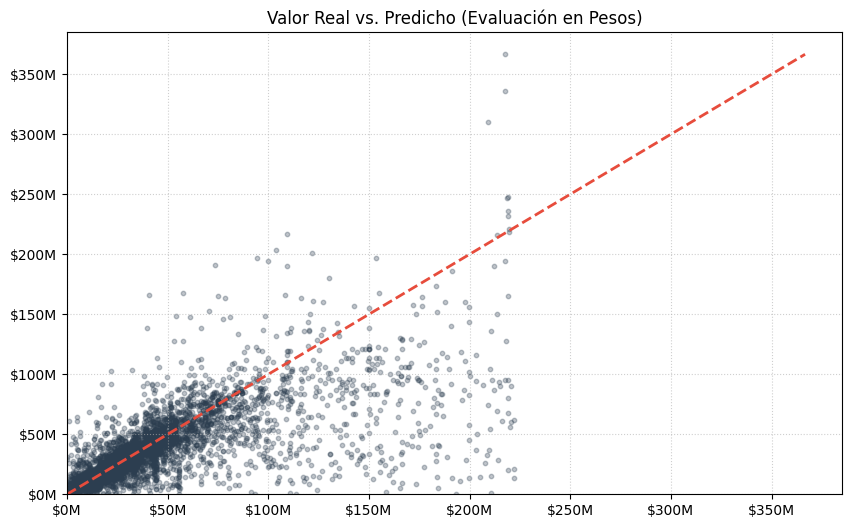

In [ ]:
from evaluar_model import evaluar_modelo
# Usamos X_test 
preds_log = model.predict(X_test)

# 7. Llamar a la función de evaluación
# Le pasamos y_test_log (valores reales) y preds_log (lo que el modelo predijo), la funcion devuelve a valores originales en pesos
evaluar_modelo(y_test_log, preds_log)

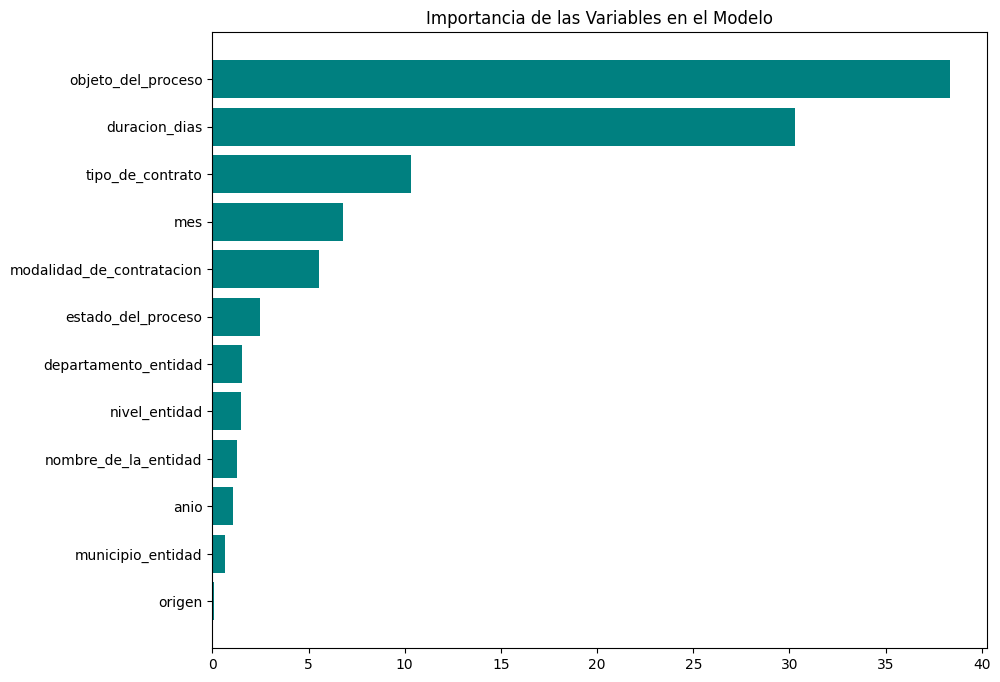

In [ ]:
from evaluar_model import graficar_importancia
# Extraemos los nombres de las columnas en el orden exacto
nombres_columnas = X_train.columns.tolist()

# Llamamos a tu función pasando el modelo entrenado y la lista de nombres
graficar_importancia(model, nombres_columnas)

## **Modelo Lightgbm**

Para este ejemplo usamos un segundo modelo Lightbm para el cual usamos (multilingual-MiniLM-L12-v2) para generar embeddings del objeto_del_proceso

llamamos el archivo con embeddings que se genero en collab.

In [ ]:
df_embeddings = pd.read_parquet(
    'data/df_model_embeddings.parquet'
)


In [ ]:
df_embeddings.sample(3)

,nivel_entidad,nombre_de_la_entidad,departamento_entidad,municipio_entidad,estado_del_proceso,modalidad_de_contratacion,tipo_de_contrato,origen,duracion_dias,anio,mes,valor_ajustado,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,emb_9,emb_10,emb_11,emb_12,emb_13,emb_14,emb_15,emb_16,emb_17,emb_18,emb_19,emb_20,emb_21,emb_22,emb_23,emb_24,emb_25,emb_26,emb_27,emb_28,emb_29,emb_30,emb_31,emb_32,emb_33,emb_34,emb_35,emb_36,emb_37,emb_38,emb_39,emb_40,emb_41,emb_42,emb_43,emb_44,emb_45,emb_46,emb_47,emb_48,emb_49,emb_50,emb_51,emb_52,emb_53,emb_54,emb_55,emb_56,emb_57,emb_58,emb_59,emb_60,emb_61,emb_62,emb_63,emb_64,emb_65,emb_66,emb_67,emb_68,emb_69,emb_70,emb_71,emb_72,emb_73,emb_74,emb_75,emb_76,emb_77,emb_78,emb_79,emb_80,emb_81,emb_82,emb_83,emb_84,emb_85,emb_86,emb_87,emb_88,emb_89,emb_90,emb_91,emb_92,emb_93,emb_94,emb_95,emb_96,emb_97,emb_98,emb_99,emb_100,emb_101,emb_102,emb_103,emb_104,emb_105,emb_106,emb_107,emb_108,emb_109,emb_110,emb_111,emb_112,emb_113,emb_114,emb_115,emb_116,emb_117,emb_118,emb_119,emb_120,emb_121,emb_122,emb_123,emb_124,emb_125,emb_126,emb_127,emb_128,emb_129,emb_130,emb_131,emb_132,emb_133,emb_134,emb_135,emb_136,emb_137,emb_138,emb_139,emb_140,emb_141,emb_142,emb_143,emb_144,emb_145,emb_146,emb_147,emb_148,emb_149,emb_150,emb_151,emb_152,emb_153,emb_154,emb_155,emb_156,emb_157,emb_158,emb_159,emb_160,emb_161,emb_162,emb_163,emb_164,emb_165,emb_166,emb_167,emb_168,emb_169,emb_170,emb_171,emb_172,emb_173,emb_174,emb_175,emb_176,emb_177,emb_178,emb_179,emb_180,emb_181,emb_182,emb_183,emb_184,emb_185,emb_186,emb_187,emb_188,emb_189,emb_190,emb_191,emb_192,emb_193,emb_194,emb_195,emb_196,emb_197,emb_198,emb_199,emb_200,emb_201,emb_202,emb_203,emb_204,emb_205,emb_206,emb_207,emb_208,emb_209,emb_210,emb_211,emb_212,emb_213,emb_214,emb_215,emb_216,emb_217,emb_218,emb_219,emb_220,emb_221,emb_222,emb_223,emb_224,emb_225,emb_226,emb_227,emb_228,emb_229,emb_230,emb_231,emb_232,emb_233,emb_234,emb_235,emb_236,emb_237,emb_238,emb_239,emb_240,emb_241,emb_242,emb_243,emb_244,emb_245,emb_246,emb_247,emb_248,emb_249,emb_250,emb_251,emb_252,emb_253,emb_254,emb_255,emb_256,emb_257,emb_258,emb_259,emb_260,emb_261,emb_262,emb_263,emb_264,emb_265,emb_266,emb_267,emb_268,emb_269,emb_270,emb_271,emb_272,emb_273,emb_274,emb_275,emb_276,emb_277,emb_278,emb_279,emb_280,emb_281,emb_282,emb_283,emb_284,emb_285,emb_286,emb_287,emb_288,emb_289,emb_290,emb_291,emb_292,emb_293,emb_294,emb_295,emb_296,emb_297,emb_298,emb_299,emb_300,emb_301,emb_302,emb_303,emb_304,emb_305,emb_306,emb_307,emb_308,emb_309,emb_310,emb_311,emb_312,emb_313,emb_314,emb_315,emb_316,emb_317,emb_318,emb_319,emb_320,emb_321,emb_322,emb_323,emb_324,emb_325,emb_326,emb_327,emb_328,emb_329,emb_330,emb_331,emb_332,emb_333,emb_334,emb_335,emb_336,emb_337,emb_338,emb_339,emb_340,emb_341,emb_342,emb_343,emb_344,emb_345,emb_346,emb_347,emb_348,emb_349,emb_350,emb_351,emb_352,emb_353,emb_354,emb_355,emb_356,emb_357,emb_358,emb_359,emb_360,emb_361,emb_362,emb_363,emb_364,emb_365,emb_366,emb_367,emb_368,emb_369,emb_370,emb_371,emb_372,emb_373,emb_374,emb_375,emb_376,emb_377,emb_378,emb_379,emb_380,emb_381,emb_382,emb_383
3300,territorial,santiago de cali distrito especial secretaria ...,valle del cauca,cali,modificado,contratacion directa,prestacion de servicios,SECOPII,68,2025,10,1.538188e+07,0.010655,0.067075,-0.004470,-0.091282,0.009537,0.055763,-0.075128,0.207745,0.072345,0.214285,-0.105933,0.059480,-0.150478,0.138355,0.044644,-0.156907,0.172151,0.057007,0.181005,0.328867,0.018400,0.192842,-0.077670,-0.239045,-0.061153,-0.150836,-0.112458,-0.219868,-0.095070,-0.132242,0.051577,-0.374487,-0.094258,0.161528,0.063104,0.183498,0.134664,0.180212,0.032279,0.158495,0.179488,-0.456454,-0.105149,0.154774,-0.129030,-0.048136,-0.230526,0.252839,-0.107474,-0.112776,-0.291184,-0.240117,0.058705,0.411013,-0.172908,0.037856,0.273721,0.023778,-0.218439,0.283581,-0.253935,0.137025,-0.433672,0.154177,-0.161340,0.211737,0.020018,-0.010168,-0.183951,-0.314091,-0.075239,-0.1602

Formar las categorias

In [ ]:

municipios = df_embeddings['municipio_entidad'].nunique()
print(f"Numero de municipios: {municipios} ")
departamentos = df_embeddings['departamento_entidad'].nunique()
print(f"Numero de departamentos: {departamentos} ")
procesos = df_embeddings['estado_del_proceso'].nunique()
print(f"Numero de estados del proceso: {procesos} ")
modalidad = df_embeddings['modalidad_de_contratacion'].nunique()
print(f"Numero de modalidades: {modalidad} ")
entidad = df_embeddings['nombre_de_la_entidad'].nunique()
print(f"Nombre de entidad: {entidad} ")
tipo_contrato = df_embeddings['tipo_de_contrato'].nunique()
print(f"tipos de contrato: {tipo_contrato} ")
modalidad = df_embeddings['modalidad_de_contratacion'].nunique()
print(f"Numero modalidades contratacion: {modalidad} ")
nivel = df_embeddings['nivel_entidad'].nunique()
print(f"Nivel entidad: {municipios} ")
estado_proceso = df_embeddings["estado_del_proceso"].nunique()
print(f"estado del proceso: {estado_proceso}")

Numero de municipios: 927 
Numero de departamentos: 35 
Numero de estados del proceso: 14 
Numero de modalidades: 13 
Nombre de entidad: 3095 
tipos de contrato: 23 
Numero modalidades contratacion: 13 
Nivel entidad: 927 
estado del proceso: 14


Para poder utilizar los datos en el modelo LightGBM, fue necesario excluir algunas columnas categóricas con alta cardinalidad, es decir, variables que contienen una gran cantidad de valores únicos.

Este tipo de variables puede aumentar considerablemente la complejidad del modelo, incrementar el consumo de memoria y afectar negativamente el rendimiento durante el entrenamiento.

Por esta razón, no se tuvieron en cuenta las columnas municipio_entidad, nombre_de_la_entidad y nivel_entidad, ya que presentan una elevada cantidad de categorías distintas y aportaban ruido al proceso de modelado.

In [ ]:
df_embeddings = df_embeddings.drop(columns=['nivel_entidad', 'municipio_entidad', 'nombre_de_la_entidad'])

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, r2_score

# 1. Target en escala log
y = np.log1p(df_embeddings['valor_ajustado'])

# 2. Features
X = df_embeddings.drop(columns=['valor_ajustado'])

# 3. Columnas categóricas
cat_features = [
    'departamento_entidad',
    'estado_del_proceso',
    'modalidad_de_contratacion',
    'tipo_de_contrato',
    'origen',
    'anio',
    'mes'
]

# 4. Convertir categóricas
for col in cat_features:
    if col in X.columns:
        X[col] = X[col].astype('category')

# 5. Verificar columnas tipo object
obj_cols = X.select_dtypes(include='object').columns

if len(obj_cols) > 0:
    print("Columnas object encontradas:")
    print(obj_cols)

# 6. Train / Test split
X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# 7. Modelo LightGBM
lgbm_model = LGBMRegressor(
    objective='regression',
    n_estimators=4000,
    learning_rate=0.05,
    num_leaves=31,
    random_state=42,
    n_jobs=-1,
    force_col_wise=True
)

# 8. Entrenamiento
print("Entrenando LightGBM con Embeddings...")

lgbm_model.fit(
    X_train,
    y_train_log,
    eval_set=[(X_test, y_test_log)],
    categorical_feature=cat_features
)

# 9. Predicciones
preds_lgbm_log = lgbm_model.predict(X_test)


Entrenando LightGBM con Embeddings...
[LightGBM] [Info] Total Bins 98287
[LightGBM] [Info] Number of data points in the train set: 51155, number of used features: 392
[LightGBM] [Info] Start training from score 16.631274


MÉTRICAS EN PESOS
MAE: $8,346,366.05
R2:  0.6307


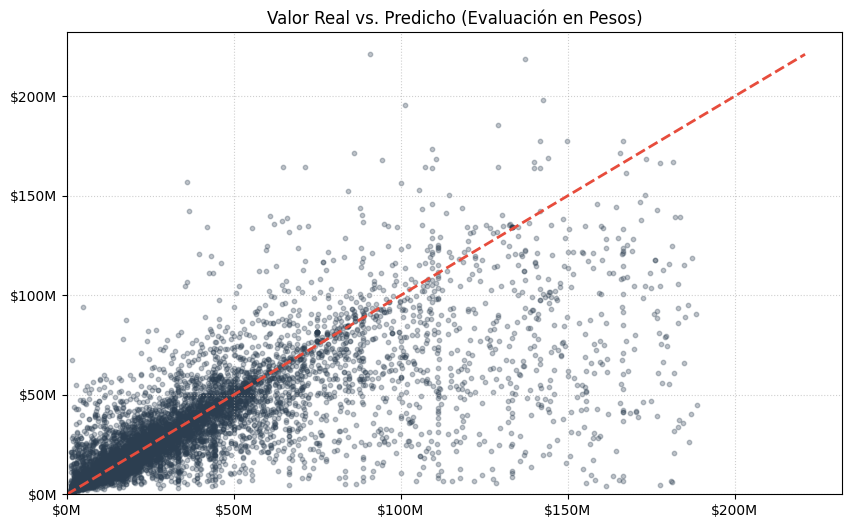

In [ ]:
from evaluar_model import evaluar_modelos
# Usamos X_test 
preds_log = lgbm_model.predict(X_test)

# 7. Llamar a la función de evaluación
# Le pasamos y_test_log (valores reales) y preds_log (lo que el modelo predijo)
evaluar_modelos(y_test_log, preds_log)

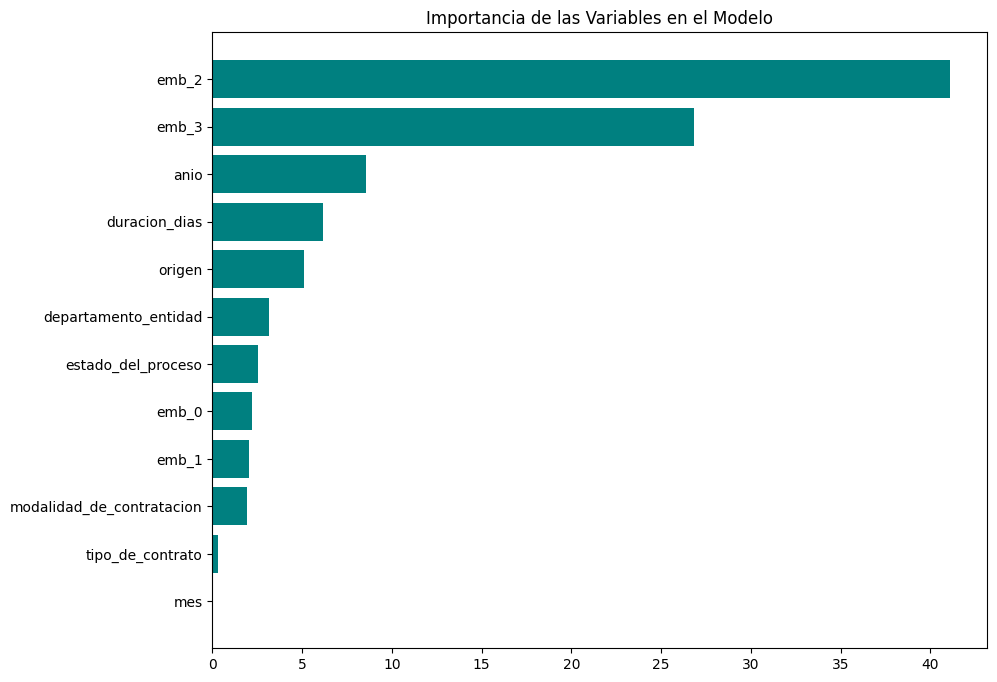

In [ ]:
from evaluar_model import graficar_importancia
# Extraemos los nombres de las columnas en el orden exacto
nombres_columnas = X_train.columns.tolist()

# Llamamos a tu función pasando el modelo entrenado y la lista de nombres
graficar_importancia(lgbm_model, nombres_columnas)

COMPARACION

In [ ]:
preds_lgbm = lgbm_model.predict(X_test)

NameError: name 'lgbm_model' is not defined

In [ ]:
preds_cat = Cat_model.predict(X_test)

SyntaxError: invalid syntax (294629488.py, line 1)

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np
import pandas as pd


def comparar_modelos(y_test_log, modelos_preds):

    resultados = []

    y_real = np.expm1(y_test_log)

    for nombre, preds_log in modelos_preds.items():

        y_pred = np.expm1(preds_log)

        mae = mean_absolute_error(y_real, y_pred)

        rmse = np.sqrt(
            mean_squared_error(y_real, y_pred)
        )

        r2 = r2_score(y_real, y_pred)

        resultados.append({
            'Modelo': nombre,
            'MAE': mae,
            'RMSE': rmse,
            'R2': r2
        })

    return pd.DataFrame(resultados).sort_values(
        by='R2',
        ascending=False
    )

In [ ]:
comparacion = comparar_modelos(
    y_test_log,
    {
        'LightGBM': preds_lgbm,
        'CatBoost': preds_cat
    }
)

comparacion